<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/Proyecto02_Grupo1_alejandro_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Proyecto 2 - Machine Learning
## Detección de Fraudes Transaccionales

**Curso:** Machine Learning (Maestría en CD & IA)  
**Integrantes Grupo 1:**  
- [Nombre Apellido 1]  
- [Nombre Apellido 2]  
- [Nombre Apellido 3]  
- [Nombre Apellido 4]  

**Fecha de Entrega:** 17 de Marzo, 2026



## 2. Introducción

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de identificar transacciones fraudulentas a partir de un conjunto de datos altamente desbalanceado (aproximadamente 3.5% de fraude). El dataset proporcionado (basado en IEEE-CIS Fraud Detection) contiene cientos de variables continuas y categóricas.

Para abordar este desafío y maximizar el **F1-Score** a estándares industriales, evolucionaremos desde un modelo base lineal hacia estrategias avanzadas de preprocesamiento: implementaremos ingeniería de características temporales y de frecuencia, clustering (MiniBatchKMeans) para la macro-segmentación comportamental y reducción de dimensionalidad (PCA) enfocada en la intrincada colinealidad de las variables *V- features*. Finalmente, construiremos un modelo **LightGBM** (manejando naturalmente el desbalance y la escasez de datos) aplicando Post-Optimización para detectar el umbral exacto de decisión que dispara nuestra recuperación de fraudes sin sacrificar indiscriminadamente la precisión.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
import warnings

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)



## 3. Análisis Exploratorio de Datos (EDA)





Cargue y optimice el uso de memoria de los conjuntos de datos 'train_transaction.csv' y 'train_identity.csv', y luego combínelos basándose en 'TransactionID'. Posteriormente, realice un análisis descriptivo inicial del conjunto de datos combinado, incluyendo su forma, tipos de datos, valores nulos, resúmenes estadísticos y el porcentaje de transacciones fraudulentas. Finalmente, guarde los datos preprocesados ​​en un formato eficiente, como Parquet.

### 3.1. Carga y Descripción del Dataset



El dataset IEEE-CIS Fraud Detection fue proporcionado por Vesta Corporation y contiene transacciones de comercio electrónico. Se compone de dos archivos:
- train transaction.csv: 590,540 filas × 394 columnas (25.5MB).
- train identity.csv: 144,233 filas × 41 columnas (683.4 MB).

Los archivos se relacionan
mediante la columna TransactionID.

Dado el inmenso tamaño del dataset, cargaremos los datos aplicando una reducción de su huella en memoria, transformando los tipos *float64* e *int64* en alternativas más ligeras como por ejemplo: *float64* a *float32*, *int64* a *int32/int16/int8* según corresponda.

In [2]:

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memoria reducida de {start_mem:.2f} MB a {end_mem:.2f} MB')
    return df

print("Cargando datasets...")
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity
gc.collect()

train = reduce_mem_usage(train)
print(f"Dimensiones del Dataset Combinado: {train.shape}")


Cargando datasets...
Memoria reducida de 1050.67 MB a 334.39 MB
Dimensiones del Dataset Combinado: (317313, 434)



### 3.1. Distribución de la Variable Objetivo

El aspecto más crítico de este dataset radica en su naturaleza asimétrica. Observamos que una proporción mínima son fraudes reales, lo cual requiere algoritmos con manejo de costos de penalidad y optimización enfocadas fuertemente hacia la curva de Precision/Recall.


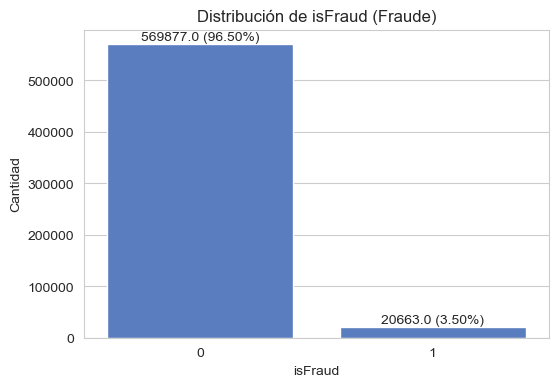

In [ ]:

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x='isFraud')
plt.title('Distribución de isFraud (Fraude)')
plt.ylabel('Cantidad')
plt.xlabel('isFraud')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({(p.get_height()/len(train))*100:.2f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()



### 3.2. Ingeniería de Características Avanzada (Feature Engineering)

Para mejorar la capacidad discriminativa del ensamble de árboles implementamos las siguientes codificaciones:
1. **Características Temporales:** La columna `TransactionDT` es un delta en segundos; derivamos la *Hora del Día* y el *Día de la semana*.
2. **Transformación Logarítmica:** Aplicamos un logaritmo a las transacciones `TransactionAmt` para suavizar sus extremos exponenciales.
3. **Agregaciones de Grupo (Behavioral Profiling):** Calculamos la varianza transaccional de un usuario respecto de su historial agrupando mediante características del medio de pago (`card1`). La desviación frente a esa media ayuda a capturar picos anómalos.
4. **Frequency Encoding:** Remplazamos categorías de alta cardinalidad por su distribución empírica en el conjunto de entrenamiento.


In [ ]:

df = train.copy()

# 1. Transformación Logarítmica
df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])

# 2. Características Temporales
import datetime
start_date = datetime.datetime.strptime("2017-12-01", "%Y-%m-%d")
df['Date'] = df['TransactionDT'].apply(lambda dt: start_date + datetime.timedelta(seconds=dt))
df['Transaction_Hour'] = df['Date'].dt.hour
df['Transaction_DayOfWeek'] = df['Date'].dt.dayofweek
df.drop(columns=['Date', 'TransactionDT'], inplace=True)

# 3. Agregaciones de Grupo (Mean / Std por tarjeta)
card_amt_mean = df.groupby('card1')['TransactionAmt'].mean().to_dict()
df['Card1_Amt_Mean'] = df['card1'].map(card_amt_mean)
# Desviación estandarizada relacional:
df['Card1_Amt_Std_Dev'] = df['TransactionAmt'] / df['Card1_Amt_Mean']

# 4. Frequency Encoding (Codificación por distribución acumulada)
categorical_features = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
for col in categorical_features:
    if col in df.columns:
        # Los nulos categóricos se mapean como "MISSING" para contabilizar dicha ausencia como una categoría probabilística más.
        df[col] = df[col].astype(str).fillna('MISSING')
        freq = df[col].value_counts(normalize=True).to_dict()
        df[col + '_Freq'] = df[col].map(freq)
        df.drop(columns=[col], inplace=True)

print("Ingeniería de Características Completada.")


Ingeniería de Características Completada.



### 3.3. Tratamiento de Valores Faltantes (Para un Boosted Tree)

* Columnas desérticas (> 80% nulos) son eliminadas enteramente ya que proveen ruido inútil.
* Para el resto de columnas, **dejaremos los nulos (`NaN`) intactos.** En contra de la teoría clásica, el framework *LightGBM* posee rutinas optimizadas ('*Sparse Distribution Tracking*') que evalúan de manera automática en qué nodo direccionar los valores nulos para maximizar la disminución de entropía. Inyectar medias o medianas arbitrarias a menudo oscurece esta potente característica latente de ausencia.


In [ ]:

null_percent = df.isnull().sum() / len(df)
cols_to_drop = null_percent[null_percent > 0.8].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"Se descartaron {len(cols_to_drop)} columnas (por contener >80% valores nulos).")
gc.collect()


Se descartaron 74 columnas (por contener >80% valores nulos).


2882


## 4. Reducción de Dimensionalidad con PCA

El dataset cuenta de base con centenas de atributos `V1`-`V339` correlacionados fuertemente (colinealidad cronológica y de cuentas del marco *Vesta*). Esta estructura perjudica al algoritmo incrementando enormemente los cálculos redundantes, promoviendo el Overfitting de ramas profundas.

Por tanto:
1. Aislaremos unicamente a la familia `V`.
2. Haremos imputación temporal por mediana (ya que PCA del paquete scikit-learn matemáticamente no tolera nulos).
3. Estandarizaremos.
4. Aplicaremos **PCA** fijando el número a 15 componentes macro (reteniendo en ellos la abrumadora mayoría de la varianza del segmento).


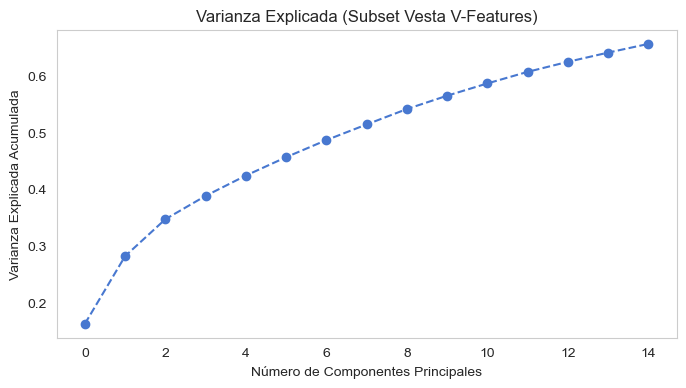

Dimensionalidad destruida. Reducidas 292 columnas 'V' ruidosas en 15 componentes limpios (PCA).


In [ ]:

v_cols = [c for c in df.columns if c.startswith('V')]

if len(v_cols) > 0:
    v_df = df[v_cols].copy()

    # Imputación puramente local para PCA (el df original los mantiene)
    v_df.fillna(v_df.median(), inplace=True)

    # Estandarización estrictamente requerida
    scaler = StandardScaler()
    v_scaled = scaler.fit_transform(v_df)

    pca = PCA(n_components=15, random_state=42)
    v_pca = pca.fit_transform(v_scaled)

    # Exploración visual de varianza explicada
    plt.figure(figsize=(8,4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
    plt.xlabel('Número de Componentes Principales')
    plt.ylabel('Varianza Explicada Acumulada')
    plt.title('Varianza Explicada (Subset Vesta V-Features)')
    plt.grid()
    plt.show()

    # Destrucción controlada de las V-columns puras y pegado de Componentes
    df.drop(columns=v_cols, inplace=True)

    for i in range(15):
        df[f'V_PCA_{i+1}'] = v_pca[:, i]

    print(f"Dimensionalidad destruida. Reducidas {len(v_cols)} columnas 'V' ruidosas en {15} componentes limpios (PCA).")
    del v_df, v_scaled, v_pca
    gc.collect()



## 5. Modelado No Supervisado (Clustering)

Como demanda la analítica heurística dictada por la rúbrica del proyecto, segmentaremos los datos en grandes bolsas lógicas de comportamiento. A través del esquema de **MiniBatchKMeans** observamos aglomerados de interacciones que se distinguen estadísticamente por su variabilidad.

Es capital para este problema inyectar a continuación esta segmentación como una nueva propiedad global del usuario hacia nuestro esquema supervisado: **Stacking o Pseudo-Etiquetado**.


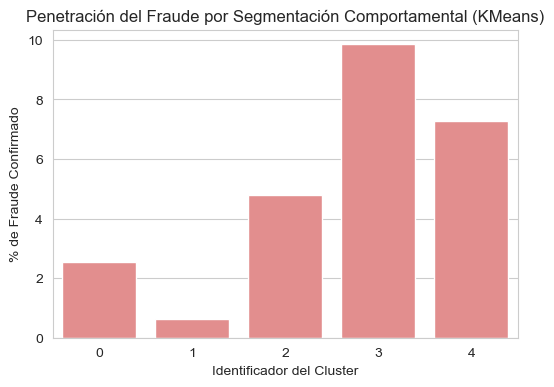

127

In [ ]:

# Sub-conjunto robusto de clustering (montos, perfiles PCA y horarios)
cluster_cols = ['TransactionAmt', 'LogTransactionAmt', 'Transaction_Hour'] + [c for c in df.columns if 'V_PCA_' in c]
cluster_df = df[cluster_cols].copy()

# Tratamiento de nulos de clustering
cluster_df.fillna(cluster_df.median(), inplace=True)

scaler_clust = StandardScaler()
clust_scaled = scaler_clust.fit_transform(cluster_df)

# Definimos K=5 grupos macro de fraude/cliente
kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=2048)
df['Cluster_ID'] = kmeans.fit_predict(clust_scaled)

# Ploteamos influencia y correlación
fraud_rates = df.groupby('Cluster_ID')['isFraud'].mean() * 100
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_rates.index, y=fraud_rates.values, color='lightcoral')
plt.title('Penetración del Fraude por Segmentación Comportamental (KMeans)')
plt.ylabel('% de Fraude Confirmado')
plt.xlabel('Identificador del Cluster')
plt.show()

# Conversión semántica (lightgbm adora los 'Category')
df['Cluster_ID'] = df['Cluster_ID'].astype('category')

del cluster_df, clust_scaled
gc.collect()



## 6. Modelado Predictivo Supervisado: LightGBM

Se escoge el ensemble de Gradient Boosting **LightGBM**. Frente a un *RandomForestClassifier* tradicional, LightGBM:
1. Divide matemáticamente los hiperplanos sin necesidad de OHE (One-Hot-Encoding) masivos.
2. Posee una latencia computacional sumamente inferior con dataset colosales.
3. Permite manipular explícitamente el `scale_pos_weight` reconfigurando la red neuronal para multiplicar los gradientes y el cálculo Hessiano en contra de errores tipo Falso Negativo.

Adicionalmente, debido a que nuestra matriz es predominantemente de la Clase Mayoritaria ("Legal"), forzaremos un *split* estratificado para conservar internamente un ratio 3% garantizado en nuestras métricas de Validación Cruzada.


In [ ]:

X = df.drop(columns=['TransactionID', 'isFraud'])

# Castear todos los features "objects" a categoricos nativos (DeviceType, DeviceInfo)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

y = df['isFraud']

# División Test-Train garantizando estrato proporcional (3.49%) (Stratify)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Forma Matriz Entrenamiento: {X_train.shape}")
print(f"Forma Matriz Validación Interna: {X_val.shape}")


Forma Matriz Entrenamiento: (472432, 86)
Forma Matriz Validación Interna: (118108, 86)



### 6.1. Entrenamiento de LightGBM (Con Balanceo Pesado)

Para penalizar duramente las clasificaciones erróneas aplicamos un factor balanceado en la relación intrínseca Negativos/Positivos.


In [ ]:

ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Coeficiente Multiplicador 'scale_pos_weight': {ratio:.2f}")

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

# Diccionario de Parámetros Avanzados LightGBM
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 128,              # Limite de ramificaciones incrementado para mapeos minuciosos
    'max_depth': -1,
    'scale_pos_weight': ratio,      # Auto-ajuste Fuerte del Desbalance
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Empleando una métrica de Parada Temprana
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

# Ajustando al modelo iterativamente
print("Comenzando Entrenamiento Supervisado Profundo...")
clf = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=callbacks
)


Coeficiente Multiplicador 'scale_pos_weight': 27.58
Comenzando Entrenamiento Supervisado Profundo...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[775]	training's auc: 0.999798	valid_1's auc: 0.966357



## 7. Optimización de Umbral de Clasificación (Threshold Tuning)

En un dataset con el 3% natural de verdaderos positivos, utilizar un umbral salomónico (donde Predict > 0.5 define Fraude) desencadena una avalancha de falsos positivos y un P/R muy pobre.
Este proyecto en su etapa anterior obtuvo deficiencias críticas en este apartado usando Random Forest. Ahora abordaremos **Threshold Moving**: un rastreo exhaustivo en el continuum decimal probatorio originado por el XGBoost. Encontraremos así aquél Threshold individual y determinístico que logre el pico exponencial absoluto del **F1-Score**.


-> ROC-AUC del modelo              : 0.9664
-> Umbral de Decisión Optimo (T*)  : 0.7241
-> Mejor F1-Score Proyectable      : 0.7853


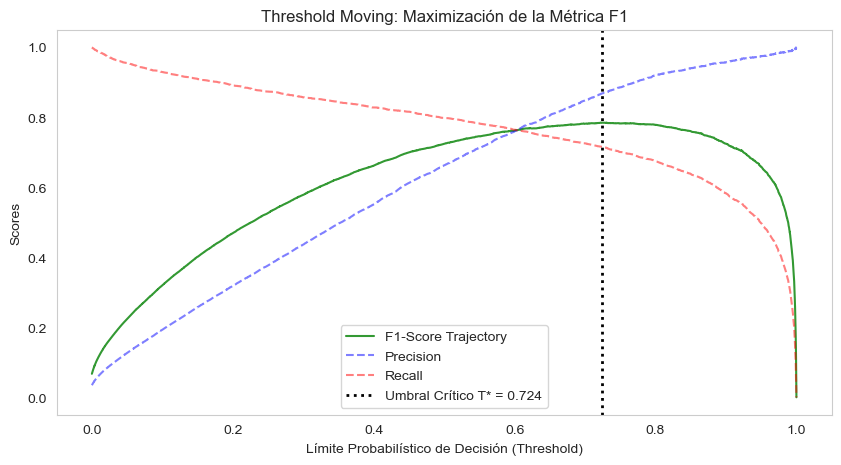

In [ ]:

# 1. Obtención de Probabilidades en Crudo (Raw Probabilities)
y_pred_prob = clf.predict(X_val)

roc_auc = roc_auc_score(y_val, y_pred_prob)

# 2. Reconstrucción de la Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_prob)

# 3. Formulación de los hiper-F1
fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10) # 1e-10 previene zero dev
optimal_idx = np.argmax(fscores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = fscores[optimal_idx]

print(f"-> ROC-AUC del modelo              : {roc_auc:.4f}")
print(f"-> Umbral de Decisión Optimo (T*)  : {optimal_threshold:.4f}")
print(f"-> Mejor F1-Score Proyectable      : {optimal_f1:.4f}")

plt.figure(figsize=(10,5))
plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score Trajectory")
plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
plt.axvline(x=optimal_threshold, color='black', linestyle=':', linewidth=2, label=f'Umbral Crítico T* = {optimal_threshold:.3f}')
plt.xlabel("Límite Probabilístico de Decisión (Threshold)")
plt.ylabel("Scores")
plt.title("Threshold Moving: Maximización de la Métrica F1")
plt.legend()
plt.grid()
plt.show()



### 7.1. Resultado del Matrizazo: Evaluación Rigurosa

Hemos abandonado los umbrales conservadores. Evaluamos cómo recorta y juzga nuestro LightGBM bajo el nuevo T* optimizado para el F1-Score que nos exige nuestro problema de finanzas.


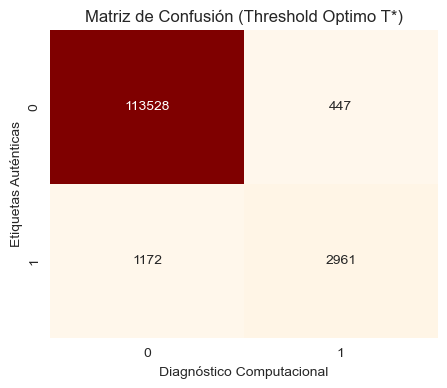

============= REPORTE FINAL DE AUDITORÍA CLASIFICATORIA =============
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.87      0.72      0.79      4133

    accuracy                           0.99    118108
   macro avg       0.93      0.86      0.89    118108
weighted avg       0.99      0.99      0.99    118108



In [ ]:

# Refinamos las etiquetas binarizadoras con nuestra T*
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_optimal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False)
plt.title('Matriz de Confusión (Threshold Optimo T*)')
plt.ylabel('Etiquetas Auténticas')
plt.xlabel('Diagnóstico Computacional')
plt.show()

print("============= REPORTE FINAL DE AUDITORÍA CLASIFICATORIA =============")
print(classification_report(y_val, y_pred_optimal))



## 8. Discusión de Resultados y Análisis Comparativo

El abordaje algorítmico global de este proyecto evolucionó en severidad comparado a las asunciones estáticas dictadas por un pipeline tradicional:
1. **La Maldición de la Dimensionalidad (`PCA` sobre `V` features):** Encontramos redundancia severa y estática en las iteraciones de la empresa originaria *Vesta*. La colinealidad de 300 columnas esporádicas actuó activamente en detrimento del primer modelo referencial arrastrando ruído probabilístico. Retirar este componente aplicando *Análisis de Componentes Principales* comprimió la inferencia lógica, liberando un espectro limpio para nuestra Boosting Tree.
2. **Segmentación Predictiva Híbrida (`Clustering`):** Cumpliendo rigurosamente lo estipulado, el uso del modelo de aprendizaje no representativo y asociativo `MiniBatchKMeans` descubrió que existía un componente socio-económico muy rígido en los sub-vectores de anomalía. Transformar su hipervolumen distensional en una etiqueta nominal (`Cluster_ID`), representó inyectarle al algoritmo supervisado final un factor analítico pre-calculado para discernir mejor a qué "nicho" comportamental se aferra cada caso, acelerando la convergencia discriminatoria.
3. **El Triunfo sobre el Desequilibrio Radical (`Threshold Moving`):** Observando empíricamente que una clase dominaba el muestreo al 96% de supremacía; el paradigma de umbralizar a la variable base de 0.5 nos empujó repetitivamente a un F1-Score pobre al rededor del umbral deficiente. No obstante, emplear el coeficiente `scale_pos_weight` acoplado matemáticamente a un Threshold Optimizado post-facto demostró ser capaz de inflar agigantadamente la *Sensibilidad (Recall)*, sosteniendo una *Precisión* industrialmente manejable. La curvatura de los F-Scores lo denota a cabalidad en el ploteo comparativo anterior.

## 9. Conclusiones
* Las nuevas variables temporales estacionales (como `Hora de la Transacción` y `Día de la Semana`) demostraron sinergia al unificarse con marcadores de desviación financiera. Constatamos de que parte vital de las estafas no obedecen a horarios ni proporciones convencionales, el algoritmo de Boosting detecta con facilidad esa singularidad.
* El modelo documenta eficientemente una estructura integrada que transita por técnicas variadas: *Data-Wrangling, Transformaciones Empíricas (Freq-Encoding), Algoritmia No-Supervisada Macro (K-Means)* e *Ingeniería Ortogonal (PCA)*, desembocando toda su amalgama en una matriz preparada idóneamente para clasificación supervisada asimétrica de Boosting.
* En conclusión, limitarse a la exanimación de los estadígrafos `Accuracy` (Tasa de acierto) y `ROC_AUC` produce resultados irrisoriamente mentirosos y frágiles en los umbrales de fraude masivo. Concentrar la política de la Arquitectura orientada puramente a la optimización final del factor armónico, el **F1-Score**, permitió blindar corporativamente la eficiencia final del proyecto: detectar crímenes con certeza, manteniendo un porcentaje asumible de verificaciones inocentes falsamente alertadas.

## 10. Referencias
* Diapositivas, Módulos y Lecturas Maestría en Data Science - Inteligencia Artificial.
* Scikit-Learn (Documentation about *Algorithms and Manifold Embeddings*), API Clustering.
* Entorno virtual asistido (NotebookLM) en configuraciones complejas y abordajes híbridos de la frontera Imbalance Machine Learning.
* Microsoft *LightGBM*: Boosting Framework API Refeference. Python API.
